# Medical Insurance Cost Prediction

Estimate recorded insurance charges from demographic and lifestyle attributes.

**Model:** Decision tree · **Target:** `charges`

Run the environment setup in the root README first, then use **Restart Kernel and Run All**. This notebook uses the same tested functions as the command line. Its output is reproducible from the committed dataset and pinned numerical dependencies.

## 1. Setup and data contract

The loader preserves raw files, excludes IDs and outcome proxies, removes identical predictor rows, and reports each cleaning step. No network is needed for this dataset.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ml_portfolio.data import ROOT, config, load_project, split_data
from ml_portfolio.models import build_model
from ml_portfolio.evaluate import fit_project, save_result

PROJECT = "insurance-cost"
spec = config(PROJECT)
X, y, audit = load_project(PROJECT)
display(pd.Series(audit, name="Data audit"))

raw_rows                                                                 1338
invalid_rows_removed                                                        0
exact_duplicates_removed                                                    1
conflicting_rows_removed                                                    4
usable_rows                                                              1333
feature_count                                                               6
sha256                      6e3894cf7d9210613f62c866684055decea694345cd4f2...
Name: Data audit, dtype: object

## 2. Reserve the holdout before exploration

The fixed 80/20 split uses seed 42. Classification splits are stratified. EDA below uses only training records. The holdout is used only for the final evaluation; it does not select parameters.

In [2]:
X_train, X_test, y_train, y_test = split_data(PROJECT, X, y)
print(f"Training: {len(y_train):,}; held out: {len(y_test):,}")
display(X_train.head())
display(X_train.describe())

Training: 1,066; held out: 267


,age,sex,bmi,children,smoker,region
1280,47,female,24.32,0,no,northeast
1110,55,male,32.67,1,no,southeast
966,34,female,23.56,0,no,northeast
598,64,female,39.05,3,no,southeast
170,49,male,30.30,0,no,southwest


,age,bmi,children
count,1066.000000,1066.000000,1066.000000
mean,39.629456,30.572162,1.099437
std,14.022471,6.118980,1.203851
min,18.000000,15.960000,0.000000
25%,27.000000,26.125000,0.000000
50%,40.000000,30.200000,1.000000
75%,52.000000,34.656250,2.000000
max,64.000000,53.130000,5.000000


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
if spec["task"] == "classification":
    y_train.value_counts().sort_index().plot.bar(ax=ax, color="#247a94")
    ax.set_ylabel("Training records")
else:
    ax.hist(y_train, bins=30, color="#247a94", edgecolor="white")
    ax.set_ylabel("Training records")
ax.set_xlabel(spec["target"])
ax.set_title("Training target distribution")
display(fig)
plt.close(fig)

<Figure size 700x400 with 1 Axes>

### Explore a relevant predictor

Compare feature distributions on the training partition. Association does not establish causation. The model's feature set is specified in the source, not selected using test-set plots.

In [4]:
training = X_train.to_frame() if X_train.ndim == 1 else X_train.copy()
training["target"] = y_train
FEATURE = "bmi"
fig, ax = plt.subplots(figsize=(8, 4))
if spec["task"] == "classification":
    for label, group in training.groupby("target"):
        ax.hist(group[FEATURE], bins=20, alpha=0.45, density=True, label=str(label))
    ax.legend(title="Target class")
    ax.set_ylabel("Density")
else:
    ax.scatter(training[FEATURE], training["target"], s=10, alpha=0.35)
    ax.set_ylabel(spec["target"])
ax.set_xlabel(FEATURE)
ax.set_title("Training-only feature exploration")
display(fig)
plt.close(fig)
display(training.isna().sum().rename("Training missing values"))

<Figure size 800x400 with 1 Axes>

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
target      0
Name: Training missing values, dtype: int64

## 3. Pipeline and model selection

Numeric features are median-imputed and scaled. Categorical features are imputed and one-hot encoded; unseen categories map to the all-zero encoding. SMS uses a vocabulary learned only from training messages. All transformations are fitted inside each CV fold.

Three shuffled folds select macro F1 for classification or negative RMSE for regression. Linear regression has no tuning grid but receives the same CV evaluation.

In [5]:
pipeline, parameter_grid = build_model(PROJECT, X_train)
display(pipeline)
print("Search space:", parameter_grid)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['age', 'bmi', 'children']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encode',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'sex',
                                                   'smoker'])])),
                ('model', DecisionTreeRegressor(random_state=42))])

Search space: {'model__max_depth': [3, 5, 8], 'model__min_samples_leaf': [5, 15]}


In [6]:
result = fit_project(PROJECT)
report = result["report"]
print("Selected parameters:", report["best_parameters"])
print("CV scoring:", report["cv_scoring"])
print("CV mean and standard deviation:", report["cv_best_score"], report["cv_score_std"])
display(pd.DataFrame(result["search"].cv_results_)[
    ["params", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score"))

Selected parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 15}
CV scoring: neg_root_mean_squared_error
CV mean and standard deviation: -4924.950954012938 190.09989052479622


,params,mean_test_score,std_test_score,rank_test_score
3,"{'model__max_depth': 5, 'model__min_samples_le...",-4924.950954,190.099891,1
2,"{'model__max_depth': 5, 'model__min_samples_le...",-4941.255827,190.519855,2
5,"{'model__max_depth': 8, 'model__min_samples_le...",-4994.320323,217.261878,3
1,"{'model__max_depth': 3, 'model__min_samples_le...",-5031.485503,218.928168,4
0,"{'model__max_depth': 3, 'model__min_samples_le...",-5031.485503,218.928168,4
4,"{'model__max_depth': 8, 'model__min_samples_le...",-5218.125825,261.741277,6


## 4. Held-out results and baseline

The dummy classifier predicts the most frequent training class; the dummy regressor predicts the training-target mean. Compare train and test performance to discuss overfitting. Macro F1 gives each class equal weight. Binary recall treats spam, malignant, or heart target 1 as positive. Regression errors retain the target units.

,model_test,dummy_test,model_train
mae,2132.148470,9114.227607,2618.893185
rmse,3529.762697,11853.242812,4445.826936
r2,0.909766,-0.017543,0.866841


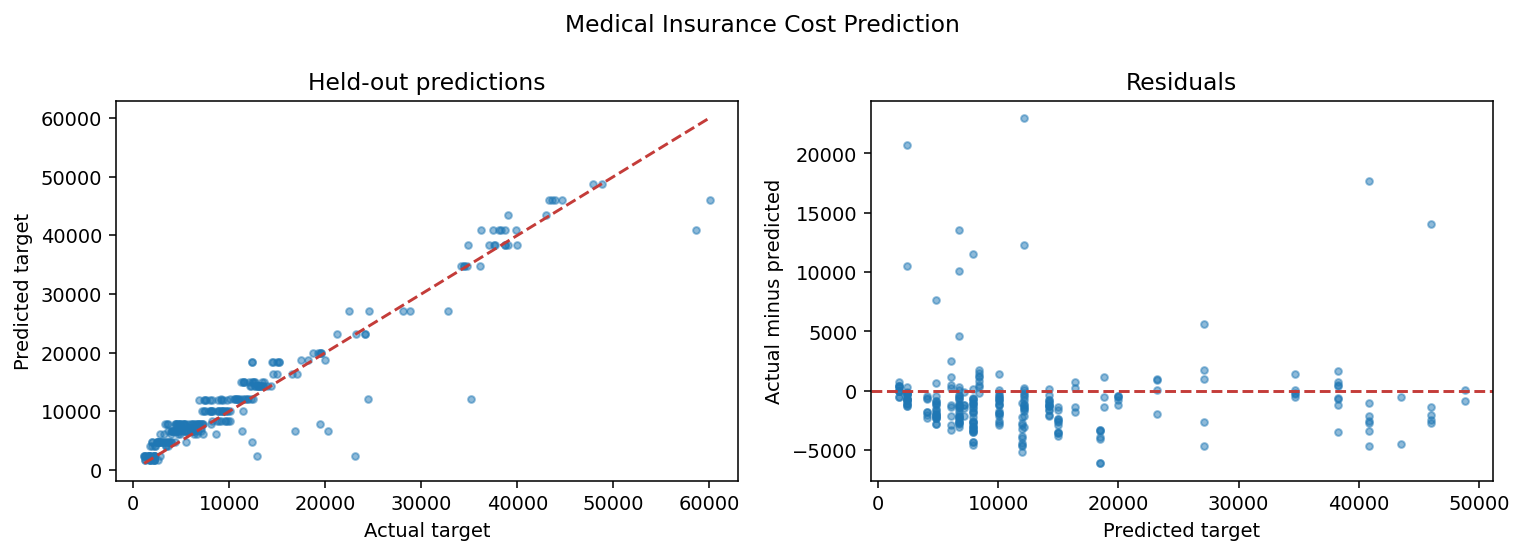

In [7]:
display(pd.DataFrame({"model_test": report["test_metrics"],
                      "dummy_test": report["baseline_metrics"],
                      "model_train": report["training_metrics"]}))
if "classification_report" in report:
    display(pd.DataFrame(report["classification_report"]).T)
output = ROOT / "reports" / PROJECT
save_result(result, output)
display(Image(filename=str(output / "diagnostics.png")))

## 5. Example predictions

These are held-out examples, not a production API. Inference accepts the cleaned feature schema produced by the loader. Inspect the source to understand encoding and feature exclusions.

In [8]:
examples = result["X_test"].iloc[:5]
display(examples)
display(pd.DataFrame({
    "actual": result["y_test"].iloc[:5].to_numpy(),
    "predicted": result["model"].predict(examples),
}))

,age,sex,bmi,children,smoker,region
898,49,male,36.850,0,no,southeast
1062,39,male,42.655,0,no,northeast
1251,51,female,36.385,3,no,northwest
298,36,male,27.550,3,no,northeast
237,44,male,38.060,1,no,southeast


,actual,predicted
0,8125.78450,10031.013592
1,5757.41345,7180.779364
2,11436.73815,10031.013592
3,6746.74250,7884.930782
4,7152.67140,10031.013592


## 6. Interpretation and next experiment

Charges are observational and highly skewed. This is not an underwriting or individual pricing tool.

Use the confusion matrix or residuals to identify the most costly errors. Before client deployment, verify data rights and feature availability, evaluate an independent population, assess subgroup performance where relevant, and define monitoring and acceptance criteria.

[Project guide](../README.md) · [Portfolio](../../../README.md) · [Evaluation protocol](../../../docs/METHODOLOGY.md)